<a href="https://colab.research.google.com/github/kduran-stack/climate_collection_kd/blob/main/R_Energy_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Energy Analysis Using R - By Kyla Duran


## Demonstration

This notebook uses the R kernel.


In [ ]:
# = pip
install.packages("tidyverse")
#= import
library(tidyverse) #tidyverse is a collection of packages useful for data science #library is how you load packages in

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# About the Data (OWID - Energy Data)

Our World In Data (OWID) is a trusted aggregator of data. Using the world's energy authorities with a varity of metrics such as energy consumption, energy and electricity mix, and more. I have done extensive research on the different energy metrics in this dataset in order to effectively analysize it and come up with my research questions which I will be answering with R. **This dataset has over 3 million data points.**

A full description of the data can be found at: https://github.com/owid/energy-data/blob/master/owid-energy-codebook.csv

Citations:
 Hannah Ritchie, Pablo Rosado, and Max Roser (2023) - “Energy” Published online at OurWorldinData.org. Retrieved from: 'https://ourworldindata.org/energy' [Online Resource]

In [ ]:

#
dataset_url <- "https://owid-public.owid.io/data/energy/owid-energy-data.csv"

#library(readr) is in the tidyverse (can just load this if you want the equivalent of pandas read.csv)

energy <- read_csv(dataset_url)

Rows: 23377 Columns: 130
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): country, iso_code
dbl (128): year, population, gdp, biofuel_cons_change_pct, biofuel_cons_chan...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


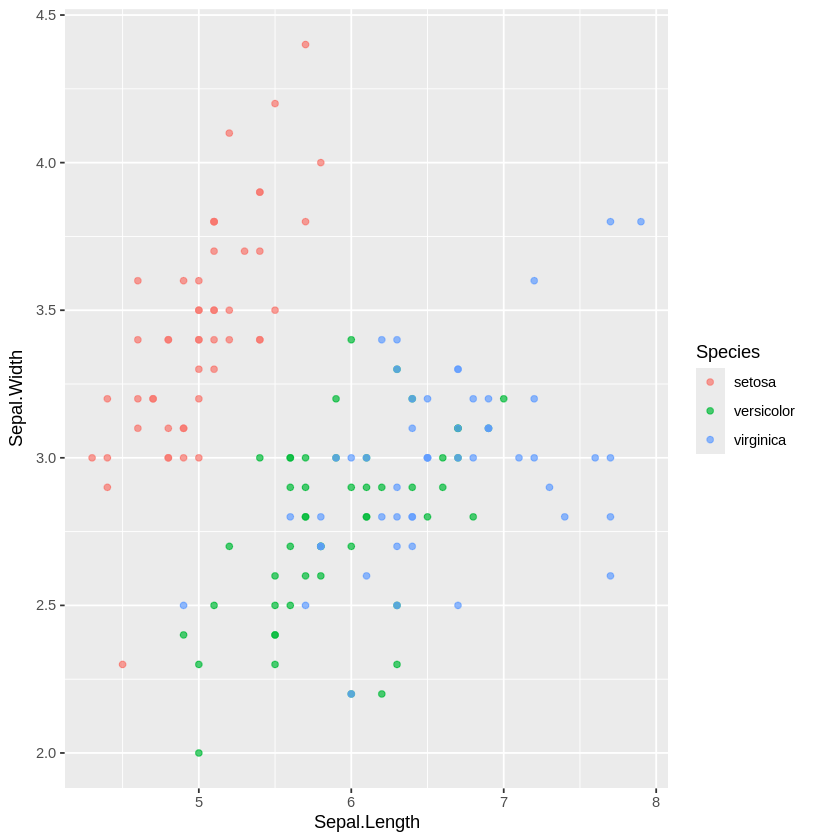

In [ ]:
iris %>%
ggplot(aes(Sepal.Length, Sepal.Width, color=Species))+
geom_point(alpha=0.7)

Notes for learning:

%>% # = and then

iso = country code

Filter, select, mutate

Need to isolate years, countries, or regions? \(\rightarrow \) Use filter() [1]Need to isolate variables, metrics, or names? \(\rightarrow \) Use select()Need to do math, percentages, or conversions? \(\rightarrow \) Use mutate()

Trying it out:

Lesson2: """
Sudo:

empty_var = dataset
empty var will now be a copy of the dataset but it will only contain data from:
the country india, from the year 2015, with these four columns of data. Country, year, coal consumption, coal electricity
"""

Lesson 3: Plotting
Lesson 4: Plotting multiple lines

In [ ]:
#lets say I wanted to open coal consumption:
#lesson 1: opening up data

View(energy)

#chr = character aka string in python
#dbl = double aka decimal floats
#other types: int, lgl = logical, <date>

In [ ]:
#lesson 2: filtering data:

#making a copy of our data



india_recent <- energy %>%
  filter(country == "India" & year > 2015) %>%
  select(country, year, coal_consumption, coal_electricity)
View(india_recent)

country,year,coal_consumption,coal_electricity
<chr>,<dbl>,<dbl>,<dbl>
India,2016,4587.692,1073.60
India,2017,4737.157,1115.24
India,2018,4981.602,1198.86
India,2019,4989.023,1198.76
India,2020,4714.672,1143.78
India,2021,5352.792,1255.56
India,2022,5561.334,1344.42
India,2023,6137.224,1445.44
India,2024,6379.826,1517.90


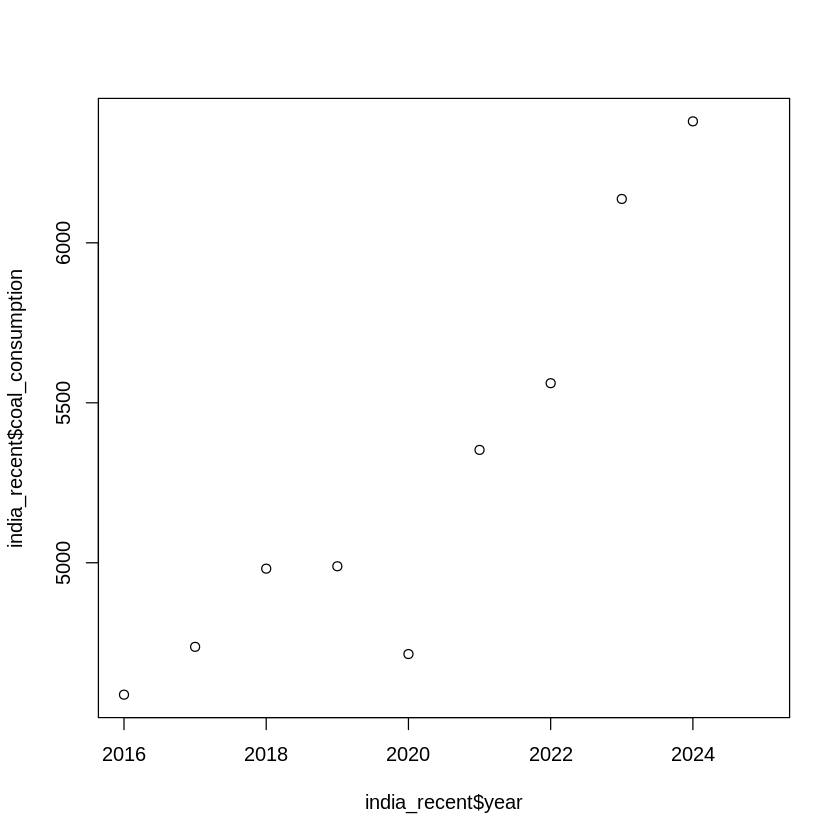

In [ ]:
plot(india_recent$year,india_recent$coal_consumption)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”


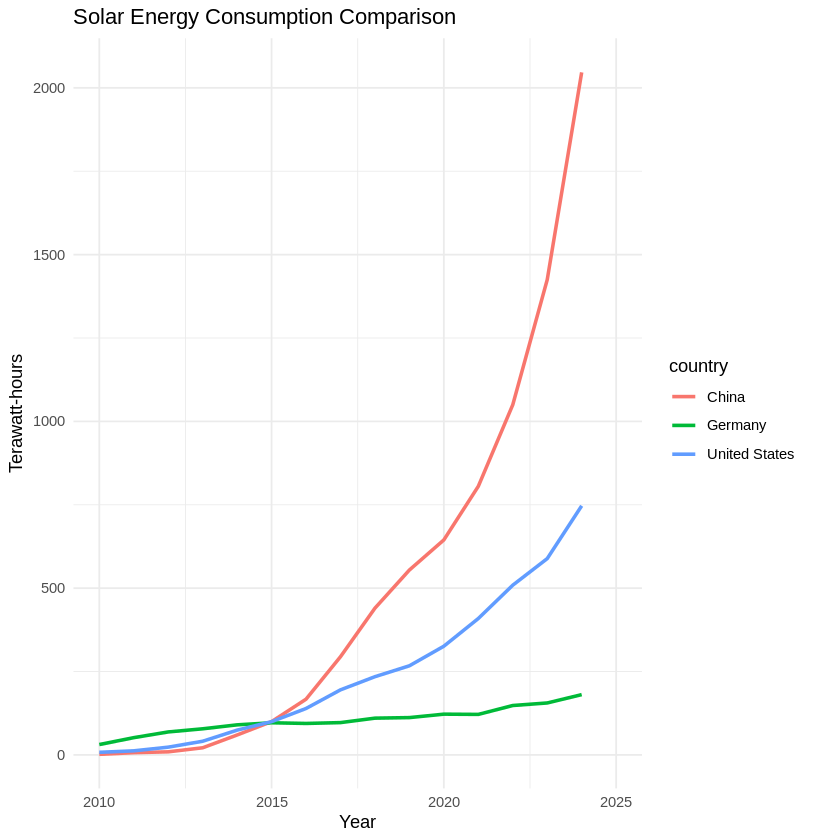

In [ ]:
# Prep data for three countries
compare_countries <- energy %>%
  filter(country %in% c("United States", "China", "Germany") & year >= 2010)

# Plot multiple lines
compare_countries %>%
  ggplot(aes(x = year, y = solar_consumption, color = country)) +
  geom_line(linewidth = 1) +
  theme_minimal() +
  labs(
    title = "Solar Energy Consumption Comparison",
    x = "Year",
    y = "Terawatt-hours"
  )
